# Tutorial: Analyze RGB images with PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit [this page for PlantCV](https://docs.plantcv.org/en/stable/installation/) and [this page for PlantCV Geospatial](https://docs.plantcv.org/projects/geospatial/en/latest/installation/). 

This tutorial is an example workflow for loading a GeoTIFF and making plot maps. This will cover basics of:
  - Loading a GeoTIFF
  - Making georeferenced plot maps
  - Exporting plot maps as GeoJSON
  - Making percent coverage measurements per plot

Note: Since this tutorial uses the napari pop-up viewer, this tutorial will only work using a local notebook.

Updated September 15, 2026

## Step 1: Load in packages and specify parameters
First, we load `plantcv.geospatial`. Here we also load the main `plantcv.plantcv.` package so that we can set our debug parameter and for checking our `outputs` class later.

In [1]:
# Set the notebook display method.
%matplotlib widget

import plantcv.plantcv as pcv
import plantcv.geospatial as gcv

pcv.params.debug = "plot"
pcv.params.sample_label = "rgb_tutorial"

# Change text size parameters
pcv.params.text_size = 25
pcv.params.text_thickness = 20

# Check that PlantCV and PlantCV-Geospatial were loaded properly by checking the version
print(pcv.__version__)
print(gcv.__version__)

5.0.0rc3.dev11+g517f48ae5
0.1.dev1281+gb382d3b1f


## Step 2: Import (aka read) in an image. 

With our parameters set we are ready to read in an image.

`gcv.read` currently supports `.geotif` and select `.netcdf` files (as more accepted standards come out of the netcdf format we may expand to include more supported types there).

`gcv.read.geotif` is used here to read in a grayscale `.tif` file. There are four arguments to `read.geotif`:
- 1: 'filename': The path to a file
- 2: 'bands': Bands to read, defaults to "R,G,B" but supports R, G, B, RE, N, NIR, and GRAY.
- 3: 'cropto': Defaults to None but can be a path to a shapefile to crop the image to.
- 4: 'cutoff': Defaults to None but can be a percentile above which to remove points in grayscale images.

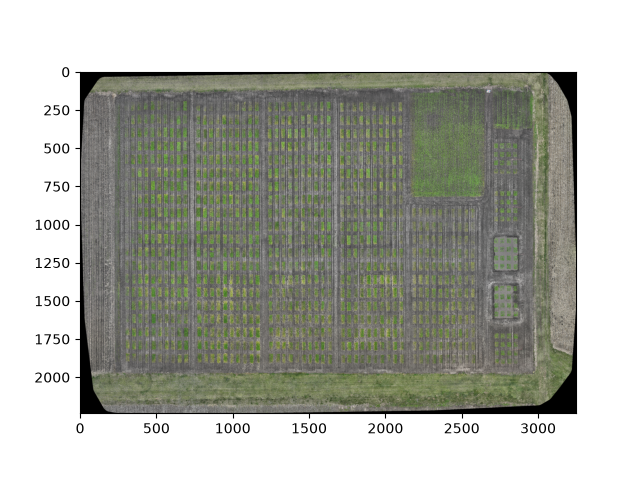

In [2]:
# Read GeoTIFF with PlantCV-Geospatial
img = gcv.read.geotif(
    filename="./img/South-Block-Color-Ortho-11-22-2024-orthophoto.tif", 
    bands="R,G,B"
    )

To keep track of important metadata when handling these images `gcv` includes two image classes, `GEO` and `DSM`.

`GEO` objects hold any multi-channel geospatial images and are a subclass of `numpy.ndarray` with special methods/attributes for a thumbnail (`thumb`), coordinate reference system (`crs`), transformations (`transfrom`), nodata values (`nodata`), wavelengths (`wavelengths`, which are numerical wavelength values found in the image metadata), and default wavelengths (`default_wavelengths`, which are a lookup table of defaults if a user inputs band names, such as NIR), and retrieving array slices from a wavelength (`get_wavelength(wavelength)`) as another `GEO` object.

## Step 3: Set plot boundaries, choose one option 

### Option A, part 1: Annotate the field boundary in Napari

The next feature of `gcv` that we'll look at is the `InteractiveShapes` class. This class works with a `napari` viewer to allow for annotation of important field coordinates.

This next cell opens a Napari window, where you can create layers. The call to `InteractiveShapes` will default to making a polygon layer called `field_boundary`, which is an important first step for our downstream analysis. In this particular case there is only one section of the field that we'll care about but often you will have to select your target area from a larger orthomosaic. 

Run the next cell, then draw the field boundary in the `field_boundary` layer in Napari.
In Napari, select `field_boundary` (it may already be selected), choose the polygon tool (the shape next to the rectangle icon), and draw the field outline by clicking vertices, then press enter. In order for the autogrid function to align properly, always start in the upper left corner of a field (not necessarily the upper left corner of the image) when drawing the boundary. 

The `InteractiveShapes` class has a `close()` method, but keep the viewer open for now to see what other functions do with it.

In [ ]:
# Open the Napari viewer by running this cell to interactively draw the field boundary. 
# In Napari, select field_boundary, choose the polygon tool, and draw the field outline, then press enter.

# For this field, we will zoom in on only one of the 10 x 20 blocks
# There are 4 blocks starting on the left side, choose one to draw a shape around
# Leave some space on the outer edge of your field, approximately half the space between each plot

editor = gcv.create_shapes.InteractiveShapes(
    img=img,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True,
    )

# Click "enter" when complete to get out of the polygon tool. Keep the napari viewer open. 

### Option A, part 2: Save the field boundary as GeoJSON

The `InteractiveShapes` class has several helpful methods, the first of which is `to_shapes`. This lets us save a polygon/rectangle layer to a geojson file.

In [5]:
#Save the polygon/rectangle layer of the field boundary as a geojson file.  
# This boundary file can be reused later to crop/reload the GeoTIFF.

editor.to_shapes(
    dest="./shape_files/rgb_tutorial_field_boundaries.geojson",
    layername="field_boundary",
    shapetype="polygon",
)

# Keep the napari viewer open. 

[[(270.9417419433594, 177.33009338378906),
  (712.5533447265625, 174.00970458984375),
  (715.873779296875, 1920.533935546875),
  (277.58251953125, 1917.2135009765625)]]

### Option A, part 3: Define plot boundaries in Napari
Once the rectangle is drawn around the field in the `field_boundary` layer, automatically draw a grid of lines to outline individual plots using the `grid` method. Adjust **[columns, ranges]** in `numdivs` if they are off until plots are covered. 

Use `field_layout` when spacing is known precisely for plots. Use `numdivs` when you just know the plot count but not the spacing, or when the spacing needs significant adjustments, such as in this example. 

In [ ]:
# Split the field boundary into plot-grid lines.
# Load the napari viewer to set the grid. 
# This field was planted with 10 columns and 20 ranges. 
# numdivs = [number of columns, number of ranges]

editor.grid(numdivs=[10, 20])

# Keep the napari viewer open. 

### Option A, part 4: Adjust the plot boundaries if needed
Adjust the gridlines using the `Select vertices` tool in napari to more precisely have plot boundaries. This is a particularly important tool in cases where fields were not planted in straight grids. After adjusting the gridlines, draw polygons using the line intersections using the `plots` method.

In [ ]:
# After adjusting grid lines in Napari, convert the grid lines into plot polygons.
# Adjust the shape or delete individual polygons in the Plots layer in Napari after if needed.

editor.plots(plot_layer="Plots")

# Keep the napari viewer open. 

### Option A, part 5: Save plot boundaries to a file

After boundaries have been adjusted, save them to a file. 

In [ ]:
# Save the plot polygon layer as a georeferenced GeoJSON.
editor.to_shapes(
    dest="./shape_files/rgb_tutorial_plot_boundaries.geojson", 
    layername="Plots", 
    shapetype="polygon"
    )

# Close your editor (the Napari viewer), either by clicking the "x" in the top right corner of the Napari viewer or by running the following command.
editor.close()


### Option B: Plot Boundaries when you have an existing shapefile. 

This option does not require Napari. If you already have a shapefile and do not need to make one, use this option. 

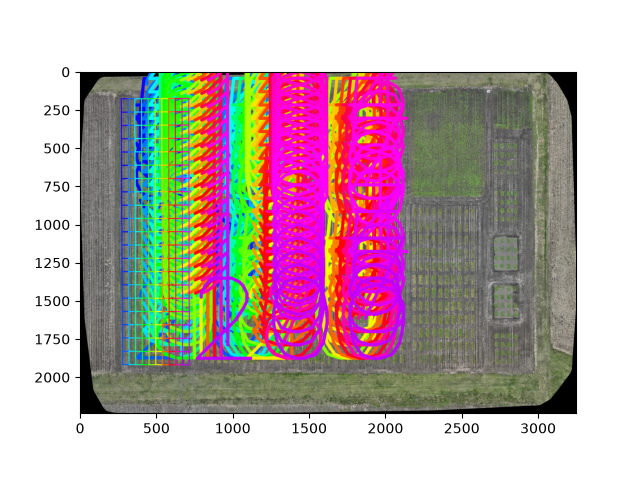

In [9]:
# Use this to load in the plot map if it already exists.
plot_rois = gcv.convert.to_roi(
    img=img, 
    geojson="./shape_files/rgb_tutorial_plot_boundaries.geojson"
    )


Since this example has an existing, accurate boundary file, we will not adjust them. We will not save out any files, since we imported them instead. 

## Step 4: Calculate RGB indices

Color is useful for determining how much of the canopy is covering the soil, since plants are generally green and soil is brown. We will calculate RGB indices, and use those indices to determine canopy coverage

/Users/katiemurphy/Documents/GitHub/plantcv/build/__editable__.plantcv-5.0.0rc3.dev11+g517f48ae5-py3-none-any/plantcv/plantcv/transform/rescale.py:32: RuntimeWarning: invalid value encountered in cast
  rescaled_img = (rescaled_img).astype('uint8')


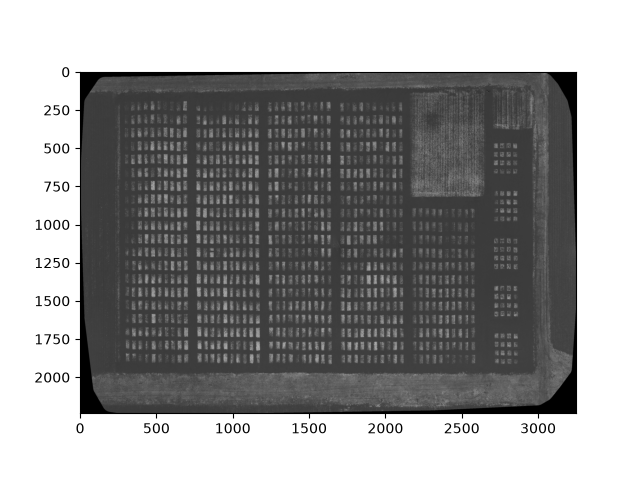

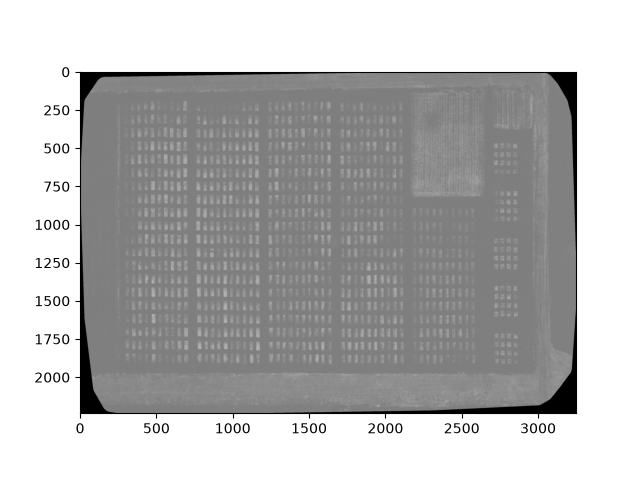

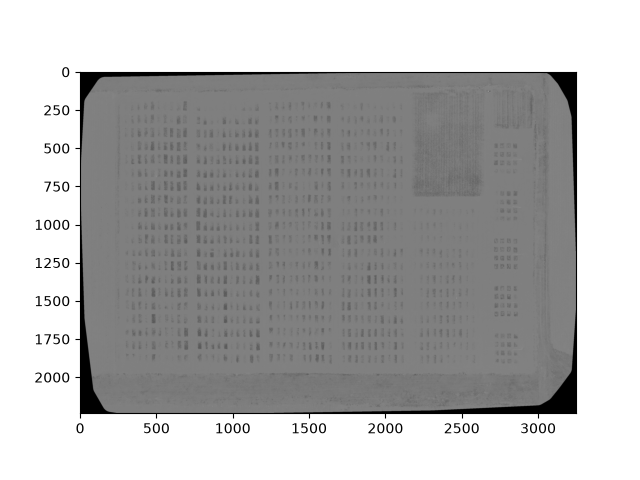

In [10]:
# Visualize RGB indices from the GeoTIFF thumbnail.
# The goal is to find one where your plants stand out from the background

# blue-green index, green leaf index, and soil color index are often useful:

bgi = pcv.spectral_index.bgi(img.thumb)
gli = pcv.spectral_index.gli(img.thumb)
sci = pcv.spectral_index.sci(img.thumb)

## Step 5: Explore colorspaces

The goal is to determine which colorspace or indice best determines plant from background or soil. Explroe all the colorspaces. 

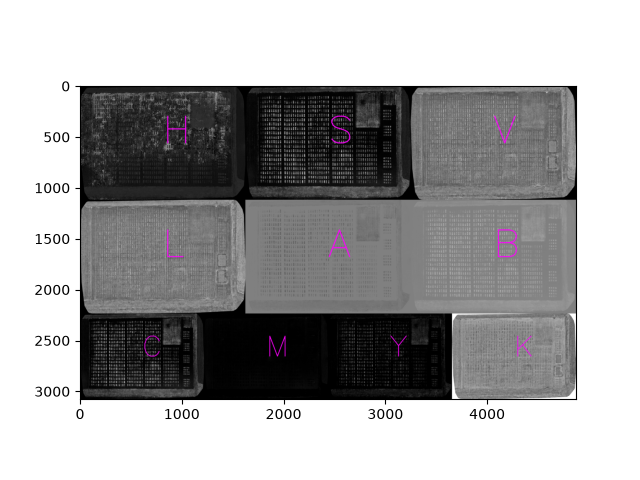

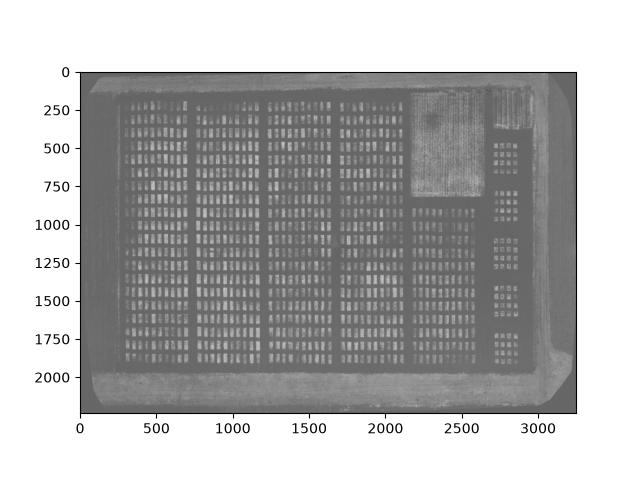

In [11]:
# View all colorspaces
colorspace_img = pcv.visualize.colorspaces(rgb_img=img.thumb, original_img=False)

# Look at the blue-yellow colorspace in grayscale
b_channel = pcv.rgb2gray_lab(rgb_img=img.thumb, channel="b")

## Step 6: Threshold the image using the chosen index or colorspace

Here, we will use the BGI index moving forward, since it best provided separation of plants from background. 

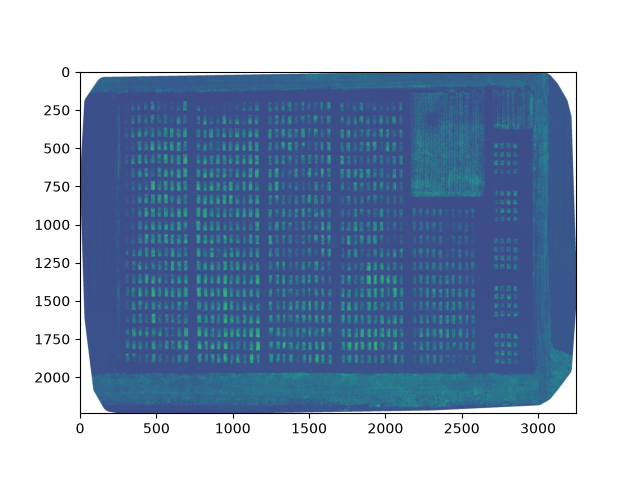

alt.Chart(...)

In [ ]:
# Plot the BGI index image in an easier to view color map. 

pcv.plot_image(bgi.array_data, cmap="viridis")

# Plot the histogram to visualize the distribution of pixel values. Determine the cutoff value in the histogram in which the plants are separated from the background. This will be used to threshold the image in the next step. 

_ = pcv.visualize.histogram(img=bgi.array_data, bins=60)

## Step 8: Create a canopy mask based on the threshold value determined. 

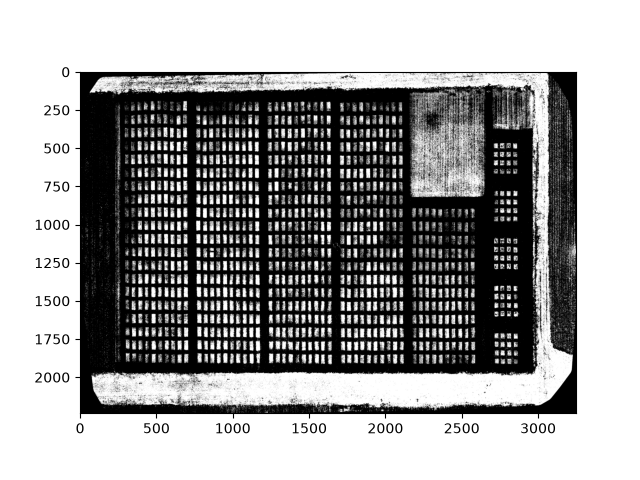

In [ ]:
# Adjust this threshold after looking at the BGI image and histogram above to generate a mask that isolates the plants from the background.

plant_mask = pcv.threshold.binary(
    gray_img=bgi.array_data,
    threshold=0.06,
    object_type="light",
)

## Step 9: Measure percent canopy coverage from the plant mask. 

Canopy coverage is defined as the percent of pixels that are plant compared to the total number of pixels. In other words, how much of the plant covers the ground? 

/Users/katiemurphy/miniforge3/envs/plantcvgeo/lib/python3.12/site-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


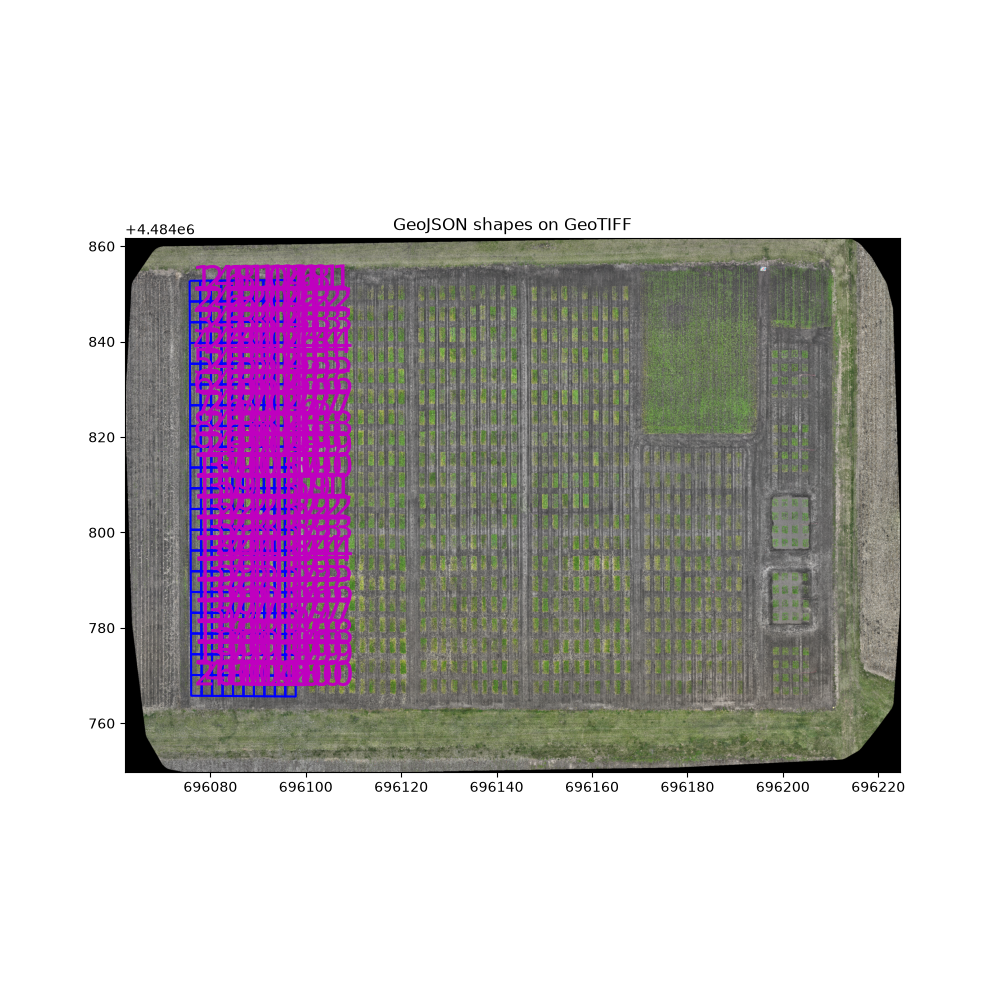

In [14]:
# Analyze percent coverage per plot.
# Requires a GeoTIFF image and a plot GeoJSON.

coverage = gcv.analyze.coverage(
    img=img,
    bin_mask=plant_mask,
    geojson="./shape_files/rgb_tutorial_plot_boundaries.geojson",
    label="coverage",
)


## Step 10a (*Optional*): View the percent coverage results if you want to see what the data looks like. 


In [15]:
from IPython.display import HTML

# Keep only plot number and percent coverage.
coverage_rows = []

for sample, obs in pcv.outputs.observations.items():
    plot_number = sample.split("_")[-1]
    percent_coverage = obs["percent_coverage"]["value"] * 100
    coverage_rows.append([plot_number, round(percent_coverage, 2)])

coverage_rows.sort(key=lambda row: int(row[0]))

html = "<table><tr><th>plot_number</th><th>percent_coverage</th></tr>"
for plot_number, percent_coverage in coverage_rows:
    html += f"<tr><td>{plot_number}</td><td>{percent_coverage}</td></tr>"
html += "</table>"

display(HTML(html))

plot_number,percent_coverage
1,3.5
2,5.05
3,12.72
4,2.98
5,12.72
6,4.39
7,8.07
8,6.77
9,9.93
10,1.8


## Step 10b: Save the percent coverage results. 


In [ ]:
# Save the results to the outputs file.

pcv.outputs.save_results(filename="./rgb_tutorial_results.csv", outformat="csv")

## Step 11 (*Optional*): Adjust the shape file to make smaller plots and reduce edge effects. 

This time create a field_bounday layer with no space around the outer edges, which whill reduce the edge effects. 

Run the next cell, then draw the field boundary in the `field_boundary` layer in Napari.
In Napari, select `field_boundary` (it may already be selected), choose the polygon tool (the shape next to the rectangle icon), and draw the field outline by clicking vertices, then press enter. In order for the autogrid function to align properly, always start in the upper left corner of a field (not necessarily the upper left corner of the image) when drawing the boundary. 

In [ ]:
# Open the Napari viewer to interactively draw the field boundary points. 
# Use the tool in the upper bar that has a + with a circle around it to add the points. 

editor = gcv.create_shapes.InteractiveShapes(
    img=img,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True,
    )

editor.add_layer(layer_type="points", layername="field_points")

# Leave the Napari viewer open. 

In [ ]:
# Save the polygon/rectangle layer of the field boundary as a geojson file. 

editor.to_points(
    dest="./shape_files/rgb_tutorial_close_crop.geojson",
    layername="field_points"
)

# Leave the Napari viewer open. 

[(278.7607404580635, 177.89670611818855),
 (704.4539387919516, 176.0047363478157),
 (708.6782731057746, 1905.6610886600952),
 (297.01415574812347, 1898.6639648523167)]

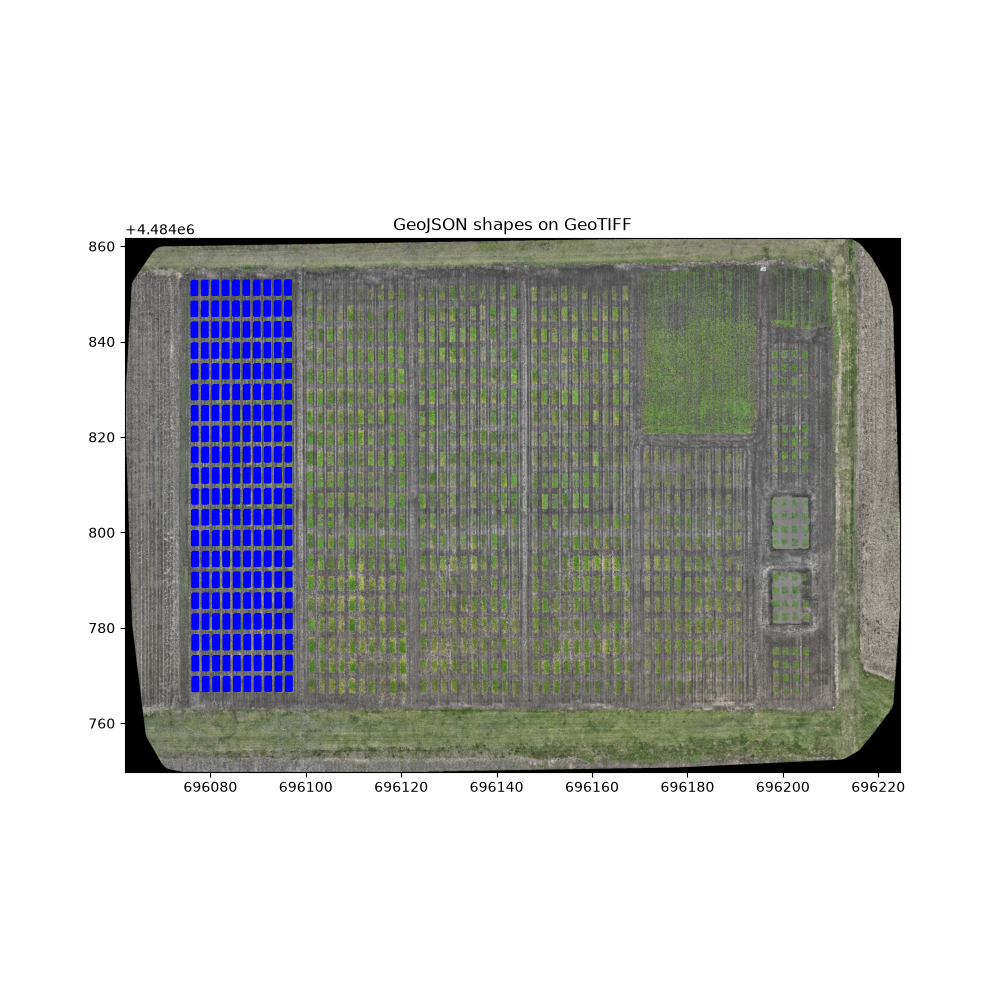

In [ ]:
# Use the auto_grid function to create a grid of individual plots. The parameters are set based on the field layout.

# The precision of your planting will determine how perfectly an automatic grid will line up
# Adjust length and spacing parameters until you capture your plots well enough 


indiv_rows = gcv.create_shapes.auto_grid(img=img, field_corners_path="./shape_files/rgb_tutorial_close_crop.geojson", 
            out_path="./rgb_tutorial_auto_grid.geojson", num_ranges=20, num_columns=10,
            num_rows=7, range_spacing=1.42, range_length=2.95, row_length=0.17, column_spacing=0.99)

# These plot boundaries can be saved and the analysis of coverage run on each row individually
# Then, in analyzing the data, you can remove outer rows to eliminate edge effects
# Alternatively, you can adjust your plot boundaries and spacing to not include edge rows in the plots at all

We hope that this is a useful getting started guide for plot boundaries in `PlantCV-Geospatial`.

For details about functions please see the [online documentation](https://docs.plantcv.org/projects/geospatial/en/latest/).

For questions about the docs, bug reports, feature requests, and other issues please open a [github issue](https://github.com/danforthcenter/plantcv-geospatial/issues) and our team will try to help!